<a href="https://colab.research.google.com/github/Ikyyy01/datasains/blob/main/Data_Mining_NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# 1. Load Dataset
df = pd.read_csv('caffeine_intake_tracker.csv')

In [ ]:
# 2. Data Discretization (Membuat Label Target)
# Karena data caffeine_mg sudah dinormalisasi (0-1), kita gunakan interval desimal.
# Rendah: 0 - 0.33 | Sedang: 0.33 - 0.66 | Tinggi: 0.66 - 1.0
bins = [0, 0.33, 0.66, 1.0]
labels = ['Rendah', 'Sedang', 'Tinggi']
df['status'] = pd.cut(df['caffeine_mg'], bins=bins, labels=labels, include_lowest=True)

In [ ]:
# 3. Preprocessing & Encoding
# Mengubah kolom teks/boolean menjadi angka
le = LabelEncoder()
for col in df.columns:

  # Encode semua kolom kecuali 'status' dan 'caffeine_mg' (karena akan didrop/dipisah)
    if col not in ['status', 'caffeine_mg']:
        if df[col].dtype == 'object' or df[col].dtype == 'bool':
            df[col] = le.fit_transform(df[col])

In [ ]:
# Encode Target secara terpisah
le_status = LabelEncoder()
df['status_encoded'] = le_status.fit_transform(df['status'])

In [ ]:
# 4. Feature Selection (PENTING: Mencegah Data Leakage)
# Hapus 'caffeine_mg' (sumber jawaban) dari fitur prediksi
X = df.drop(['caffeine_mg', 'status', 'status_encoded'], axis=1)
y = df['status_encoded']

In [ ]:
# 5. Split Data (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# 6. Modeling (Gaussian Naive Bayes)
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [ ]:
# 7. Evaluasi
y_pred = model.predict(X_test)

print("=== HASIL EVALUASI MODEL ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

=== HASIL EVALUASI MODEL ===
Akurasi: 0.70

Confusion Matrix:
[[50 21  2]
 [ 0 50  9]
 [ 0 13  5]]

Classification Report:
              precision    recall  f1-score   support

      Rendah       1.00      0.68      0.81        73
      Sedang       0.60      0.85      0.70        59
      Tinggi       0.31      0.28      0.29        18

    accuracy                           0.70       150
   macro avg       0.64      0.60      0.60       150
weighted avg       0.76      0.70      0.71       150



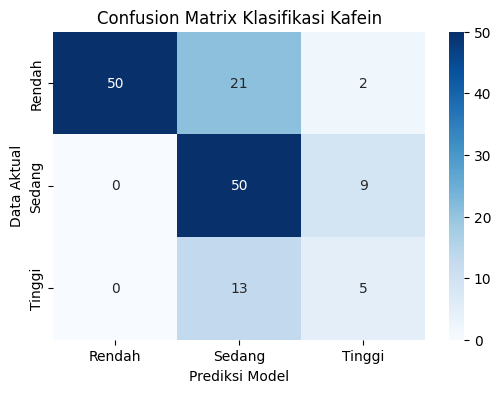

In [ ]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.title('Confusion Matrix Klasifikasi Kafein')
plt.show()